In [20]:
from google.colab import drive
drive.mount('/content/drive')

PROJ = '/content/drive/MyDrive/TAC_459/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [22]:
data = pd.read_csv(PROJ + "all_tickets.csv")
data

,title,body,ticket_type,category,sub_category1,sub_category2,business_service,urgency,impact
0,NaN,hi since recruiter lead permission approve req...,1,4,2,21,71,3,4
1,connection with icon,icon dear please setup icon per icon engineers...,1,6,22,7,26,3,4
2,work experience user,work experience user hi work experience studen...,1,5,13,7,32,3,4
3,requesting for meeting,requesting meeting hi please help follow equip...,1,5,13,7,32,3,4
4,reset passwords for external accounts,re expire days hi ask help update passwords co...,1,4,2,76,4,3,4
...,...,...,...,...,...,...,...,...,...
48544,git space for a project issues with adding users,sent tuesday july re git space for hi got righ...,0,4,21,1,39,1,3
48545,error,sent july error hi guys can you help out with ...,0,4,9,41,10,2,3
48546,connection issues,sent tuesday july connection issues hello have...,0,5,32,0,32,2,3
48547,error cube reports,sent tuesday july error hello guys have receiv...,0,4,21,41,35,1,3


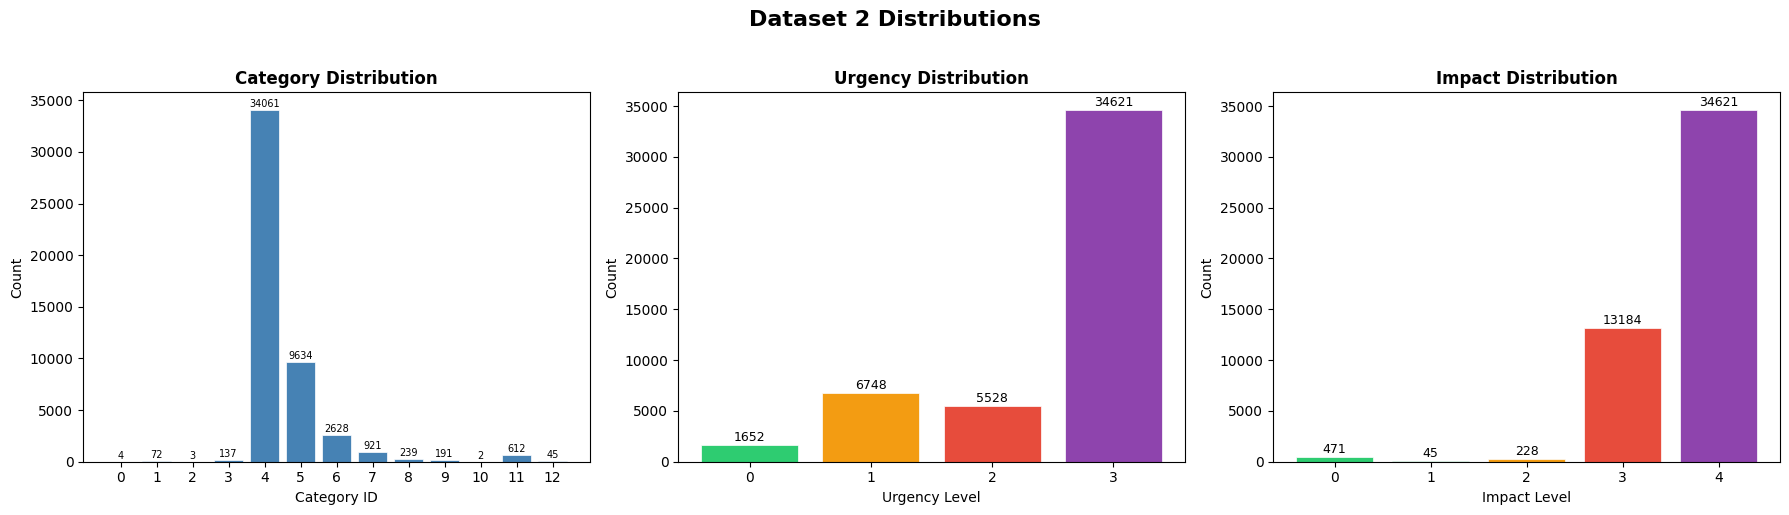


--- Value Counts ---

Category:
 category
0         4
1        72
2         3
3       137
4     34061
5      9634
6      2628
7       921
8       239
9       191
10        2
11      612
12       45
Name: count, dtype: int64

Urgency:
 urgency
0     1652
1     6748
2     5528
3    34621
Name: count, dtype: int64

Impact:
 impact
0      471
1       45
2      228
3    13184
4    34621
Name: count, dtype: int64


In [23]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset 2 Distributions', fontsize=16, fontweight='bold', y=1.02)

# Category
cat_counts = data['category'].value_counts().sort_index()
axes[0].bar(cat_counts.index, cat_counts.values, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Category Distribution', fontweight='bold')
axes[0].set_xlabel('Category ID')
axes[0].set_ylabel('Count')
axes[0].set_xticks(cat_counts.index)
for bar, count in zip(axes[0].patches, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 str(count), ha='center', va='bottom', fontsize=7)

# Urgency
urg_counts = data['urgency'].value_counts().sort_index()
colors_urg = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
axes[1].bar(urg_counts.index, urg_counts.values,
            color=[colors_urg[i] for i in urg_counts.index], edgecolor='white', linewidth=0.5)
axes[1].set_title('Urgency Distribution', fontweight='bold')
axes[1].set_xlabel('Urgency Level')
axes[1].set_ylabel('Count')
axes[1].set_xticks(urg_counts.index)
for bar, count in zip(axes[1].patches, urg_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 str(count), ha='center', va='bottom', fontsize=9)

# Impact
imp_counts = data['impact'].value_counts().sort_index()
colors_imp = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#8e44ad']
axes[2].bar(imp_counts.index, imp_counts.values,
            color=[colors_imp[i] for i in imp_counts.index], edgecolor='white', linewidth=0.5)
axes[2].set_title('Impact Distribution', fontweight='bold')
axes[2].set_xlabel('Impact Level')
axes[2].set_ylabel('Count')
axes[2].set_xticks(imp_counts.index)
for bar, count in zip(axes[2].patches, imp_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Quick summary stats
print("\n--- Value Counts ---")
print("\nCategory:\n", data['category'].value_counts().sort_index())
print("\nUrgency:\n", data['urgency'].value_counts().sort_index())
print("\nImpact:\n", data['impact'].value_counts().sort_index())

In [24]:
from sklearn.model_selection import train_test_split

# --- Filter micro-categories ---
VALID_CATS = [4, 5, 6, 7, 8, 9, 11]
df = data[data['category'].isin(VALID_CATS)].copy()
df = df.dropna(subset=['body'])  # body is required; title can be NaN

# --- Build input text: title [SEP] body ---
df['text'] = df['title'].fillna('') + ' [SEP] ' + df['body']
df['text'] = df['text'].str.strip()

# --- Normalize urgency to [0, 1] ---
# urgency is 0-3; 3 = most urgent
df['urgency_norm'] = df['urgency'] / 3.0

print(f"Dataset size after filtering: {len(df)}")
print(f"Urgency distribution:\n{df['urgency'].value_counts().sort_index()}")

X = df['text'].tolist()
y = df['urgency_norm'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=df['urgency'].tolist()
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Dataset size after filtering: 48286
Urgency distribution:
urgency
0     1650
1     6637
2     5510
3    34489
Name: count, dtype: int64
Train: 34886 | Val: 6157 | Test: 7243


In [25]:
X_train

['error time card [SEP] error card please help thank you',
 'new for [SEP] dear please change name thank blvd floor district',
 'cannot access [SEP] cannot access hi cannot access fallowing link get blank cannot proceed can you please help with thanks',
 'quality profiles migrations [SEP] profiles migrations dear colleagues please log migration profiles instance instance order prepare migration thank engineer',
 'access to confluence [SEP] tuesday pm confluence please confluence asap thanks date tuesday confluence hi confluence profile please search choose third search result then spaces directory too alternatively share folder drive easier everyone tomorrow dailies cheers digital upcoming leave',
 'employee details report [SEP] details report hi please help updating report details needed country number type holder name branch branch number code sort code example these details attached please thank much analyst',
 'new list [SEP] wednesday july hi please help creating named where pleas

In [26]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
import torch.nn as nn
from transformers import BertModel
from torch.optim import AdamW
from sklearn.metrics import mean_absolute_error
import numpy as np



tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN = 128
BATCH_SIZE = 32

In [27]:



class TicketDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.float)
        }

train_dataset = TicketDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = TicketDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = TicketDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches — Train: 1091 | Val: 193 | Test: 227


In [28]:

class BertUrgencyRegressor(nn.Module):
    def __init__(self, dropout=0.3, freeze_bert=True):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(self.bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.pooler_output          # [CLS] token, shape (B, 768)
        cls = self.dropout(cls)
        score = torch.sigmoid(self.regressor(cls))  # (B, 1) in [0,1]
        return score.squeeze(1)                     # (B,)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")



Using device: cuda


In [ ]:
# Initializing with freeze_bert=True
model = BertUrgencyRegressor(dropout=0.3, freeze_bert=True).to(device)

In [29]:

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.MSELoss()
NUM_EPOCHS = 5

In [30]:
model_save_path = PROJ + 'bert_urgency_regressor.pth'

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for i, batch in enumerate(loader):
        input_ids     = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels        = batch['label'].to(device)

        optimizer.zero_grad()
        preds = model(input_ids, attention_mask)
        loss  = criterion(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        print(f"[Batch {i}/{len(loader)}]: loss={loss.item()}")
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            preds = model(input_ids, attention_mask)
            loss  = criterion(preds, labels)
            total_loss += loss.item()

            # Denormalize back to 0-3 for interpretable MAE
            all_preds.extend((preds.cpu().numpy() * 3).tolist())
            all_labels.extend((labels.cpu().numpy() * 3).tolist())
            print(f"Batch {i}/{len(loader)}")

    mae = mean_absolute_error(all_labels, all_preds)
    return total_loss / len(loader), mae

In [ ]:



# --- Training loop ---
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_mae = eval_epoch(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.4f}")
    print("-" * 55)

torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Streaming output truncated to the last 5000 lines.
[Batch 145/1091]: loss=0.056021612137556076
[Batch 146/1091]: loss=0.07359597086906433
[Batch 147/1091]: loss=0.08361615240573883
[Batch 148/1091]: loss=0.06753861904144287
[Batch 149/1091]: loss=0.03616184741258621
[Batch 150/1091]: loss=0.10272955894470215
[Batch 151/1091]: loss=0.10989539325237274
[Batch 152/1091]: loss=0.11328702419996262
[Batch 153/1091]: loss=0.07475453615188599
[Batch 154/1091]: loss=0.06887628883123398
[Batch 155/1091]: loss=0.05603949353098869
[Batch 156/1091]: loss=0.09736935794353485
[Batch 157/1091]: loss=0.07627659291028976
[Batch 158/1091]: loss=0.06897978484630585
[Batch 159/1091]: loss=0.08865360915660858
[Batch 160/1091]: loss=0.05552762746810913
[Batch 161/1091]: loss=0.08123451471328735
[Batch 162/1091]: loss=0.061172932386398315
[Batch 163/1091]: loss=0.05988764762878418
[Batch 164/1091]: loss=0.05351758003234863
[Batch 165/1091]: loss=0.08323051780462265
[Batch 166/1091]: loss=0.11112338304519653
[

### Experiment 2: Full Fine-Tuning
In this regime, we unfreeze all BERT weights from the start. We typically use a very small learning rate (like 2e-5) to avoid catastrophic forgetting.

In [ ]:
model_full = BertUrgencyRegressor(dropout=0.3, freeze_bert=False).to(device)
optimizer_full = AdamW(model_full.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.MSELoss()
model_save_path_full = PROJ + 'bert_urgency_full_finetune.pth'

print("Starting Full Fine-Tuning Training...")
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model_full, train_loader, optimizer_full, criterion, device)
    val_loss, val_mae = eval_epoch(model_full, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.4f}")

torch.save(model_full.state_dict(), model_save_path_full)
print(f"Full fine-tuned model saved to {model_save_path_full}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Streaming output truncated to the last 5000 lines.
[Batch 141/1091]: loss=0.0144859179854393
[Batch 142/1091]: loss=0.008905303664505482
[Batch 143/1091]: loss=0.007717790547758341
[Batch 144/1091]: loss=0.010296850465238094
[Batch 145/1091]: loss=0.030924158170819283
[Batch 146/1091]: loss=0.010446127504110336
[Batch 147/1091]: loss=0.016079049557447433
[Batch 148/1091]: loss=0.007028897292912006
[Batch 149/1091]: loss=0.007915240712463856
[Batch 150/1091]: loss=0.01787903904914856
[Batch 151/1091]: loss=0.005676975008100271
[Batch 152/1091]: loss=0.0052914805710315704
[Batch 153/1091]: loss=0.018973561003804207
[Batch 154/1091]: loss=0.01879091188311577
[Batch 155/1091]: loss=0.009712106548249722
[Batch 156/1091]: loss=0.010332738049328327
[Batch 157/1091]: loss=0.011874140240252018
[Batch 158/1091]: loss=0.028407219797372818
[Batch 159/1091]: loss=0.008694394491612911
[Batch 160/1091]: loss=0.007725890260189772
[Batch 161/1091]: loss=0.03073243610560894
[Batch 162/1091]: loss=0.0109

### Experiment 3: Warmup / Mixed Strategy
Here, we keep BERT frozen for the first epoch to let the randomly initialized regressor head converge. Then, we unfreeze BERT for the remaining epochs.

In [ ]:
model_mixed = BertUrgencyRegressor(dropout=0.3, freeze_bert=True).to(device)
optimizer_mixed = AdamW(model_mixed.parameters(), lr=2e-5, weight_decay=0.01)
model_save_path_mixed = PROJ + 'bert_urgency_warmup_strategy.pth'

print("Starting Warmup/Mixed Strategy Training...")
for epoch in range(NUM_EPOCHS):
    if epoch == 1:
        print("--- Unfreezing BERT weights for the remainder of training ---")
        for param in model_mixed.bert.parameters():
            param.requires_grad = True
        # Re-initialize optimizer to include BERT parameters
        optimizer_mixed = AdamW(model_mixed.parameters(), lr=2e-5, weight_decay=0.01)

    train_loss = train_epoch(model_mixed, train_loader, optimizer_mixed, criterion, device)
    val_loss, val_mae = eval_epoch(model_mixed, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.4f}")

torch.save(model_mixed.state_dict(), model_save_path_mixed)
print(f"Warmup strategy model saved to {model_save_path_mixed}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Streaming output truncated to the last 5000 lines.
[Batch 141/1091]: loss=0.019236117601394653
[Batch 142/1091]: loss=0.01811460591852665
[Batch 143/1091]: loss=0.03843693062663078
[Batch 144/1091]: loss=0.023244094103574753
[Batch 145/1091]: loss=0.03929490968585014
[Batch 146/1091]: loss=0.01065422035753727
[Batch 147/1091]: loss=0.04470950365066528
[Batch 148/1091]: loss=0.009909539483487606
[Batch 149/1091]: loss=0.02354000136256218
[Batch 150/1091]: loss=0.019174326211214066
[Batch 151/1091]: loss=0.026879001408815384
[Batch 152/1091]: loss=0.02514752559363842
[Batch 153/1091]: loss=0.010210671462118626
[Batch 154/1091]: loss=0.019692936912178993
[Batch 155/1091]: loss=0.02105054259300232
[Batch 156/1091]: loss=0.007496821694076061
[Batch 157/1091]: loss=0.014512784779071808
[Batch 158/1091]: loss=0.013399725779891014
[Batch 159/1091]: loss=0.02787942625582218
[Batch 160/1091]: loss=0.028876984491944313
[Batch 161/1091]: loss=0.018154039978981018
[Batch 162/1091]: loss=0.022627081

In [32]:
from torch.optim import AdamW
import torch.nn as nn

model_save_path_refined = PROJ + 'bert_urgency_refined.pth'
model = BertUrgencyRegressor(dropout=0.3, freeze_bert=True).to(device)


def set_bert_layers_frozen(model, frozen=True):
    """Freeze or unfreeze all BERT parameters."""
    for param in model.bert.parameters():
        param.requires_grad = not frozen

def set_bert_top_layers_unfrozen(model, layers=[9, 10, 11]):
    """Unfreeze specific BERT encoder layers only."""
    for i in layers:
        for param in model.bert.encoder.layer[i].parameters():
            param.requires_grad = True

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

criterion = nn.MSELoss()

schedule = [
    # (epochs, freeze_mode, lr)
    (3, 'head_only',   2e-5),
    (4, 'top_layers',  1e-5),
    (3, 'all',         5e-6),
]

epoch_num = 0
for (num_epochs, mode, lr) in schedule:

    # --- Set frozen/unfrozen state ---
    if mode == 'head_only':
        set_bert_layers_frozen(model, frozen=True)
        # Always keep pooler and head unfrozen
        for param in model.bert.pooler.parameters():
            param.requires_grad = True
    elif mode == 'top_layers':
        set_bert_layers_frozen(model, frozen=True)
        set_bert_top_layers_unfrozen(model, layers=[9, 10, 11])
        for param in model.bert.pooler.parameters():
            param.requires_grad = True
    elif mode == 'all':
        set_bert_layers_frozen(model, frozen=False)

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=0.01
    )

    print(f"\n{'='*55}")
    print(f"Phase: {mode} | LR: {lr} | Trainable params: {count_trainable(model):,}")
    print(f"{'='*55}")

    for epoch in range(num_epochs):
        epoch_num += 1
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_mae = eval_epoch(model, val_loader, criterion, device)
        print(f"Epoch {epoch_num:02d} [{mode}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.4f}")

torch.save(model.state_dict(), model_save_path_refined)
print(f"\nRefined model saved to {model_save_path_refined}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Streaming output truncated to the last 5000 lines.
[Batch 146/1091]: loss=0.0019958307966589928
[Batch 147/1091]: loss=0.017489196732640266
[Batch 148/1091]: loss=0.018306972458958626
[Batch 149/1091]: loss=0.021254179999232292
[Batch 150/1091]: loss=0.012973487377166748
[Batch 151/1091]: loss=0.01785709336400032
[Batch 152/1091]: loss=0.00867399014532566
[Batch 153/1091]: loss=0.010701710358262062
[Batch 154/1091]: loss=0.024966897442936897
[Batch 155/1091]: loss=0.008829906582832336
[Batch 156/1091]: loss=0.01893509551882744
[Batch 157/1091]: loss=0.017519481480121613
[Batch 158/1091]: loss=0.007664339616894722
[Batch 159/1091]: loss=0.009968627244234085
[Batch 160/1091]: loss=0.013068435713648796
[Batch 161/1091]: loss=0.015593166463077068
[Batch 162/1091]: loss=0.01768386736512184
[Batch 163/1091]: loss=0.005639347247779369
[Batch 164/1091]: loss=0.00676619540899992
[Batch 165/1091]: loss=0.011101759038865566
[Batch 166/1091]: loss=0.012240813113749027
[Batch 167/1091]: loss=0.0253

# INFERENCE ON SAVED MODELS!

In [33]:
def load_urgency_model(model_path, device=None):
    """Load a saved BertUrgencyRegressor from disk."""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = BertUrgencyRegressor(dropout=0.3).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print(f"Model loaded from {model_path} on {device}")
    return model

In [34]:
def predict_urgency(text, model, tokenizer=tokenizer, max_len=128, device=None):
    """
    Takes a raw ticket string, returns urgency as a float in [0, 3].
    Higher = more urgent.
    """
    if device is None:
        device = next(model.parameters()).device

    text = ' '.join(text.strip().split())

    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        score = model(input_ids, attention_mask)

    urgency = 3.0 - (score.item() * 3.0)  # flip: higher = more urgent
    return urgency

In [35]:
model = load_urgency_model(model_save_path_refined)

samples = [
    "server is completely down cannot access anything urgent",
    "please update my profile picture when you get a chance",
    "cannot connect to vpn blocking all work need immediate help",
    "question about subscription renewal next month",
]
for s in samples:
    print(f"{predict_urgency(s, model):.3f} | {s}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded from /content/drive/MyDrive/TAC_459/bert_urgency_refined.pth on cuda
2.861 | server is completely down cannot access anything urgent
1.429 | please update my profile picture when you get a chance
2.167 | cannot connect to vpn blocking all work need immediate help
0.211 | question about subscription renewal next month
